<a href="https://colab.research.google.com/github/suyon0416/26-2_ESAA_YB/blob/main/ESSA_YB_WEEK2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 시본(seaborn)
: 데이터 시각화 라이브러리. Matplotlib을 기반으로 만들어짐.
### 01. 정보 종류에 따른 시각화 차트 유형
- 히스토그램: 연속형 값에 대한 도수 분포
- 바 플롯: 특정 칼럼의 이산 값에 따른 다른 칼럼의 연속형 값을 막대로 시각화
- 박스 플롯: 연속형 값의 사분위 IQR과 최대, 최소, 이상치 값을 시각화
- 바이올린 플롯: 히스토그램의 연속 확률 분포 곡선과 박스 플롯을 바이올린 형태로 함께 시각화
- 스캐터 플롯(산점도): 2개의 연속형 값들을 x,y 좌표상의 점으로 시각화
- 상관 히트맵: 다수의 연속형 칼럼들에 대해서 상호 간의 상관 관계를 시각화


<히스토그램>

: hisplot()은 Axes 레벨 함수, displot()은 Figure 레벨 함수

In [2]:
import pandas as pd

titanic_df=pd.read_csv('train.csv')
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


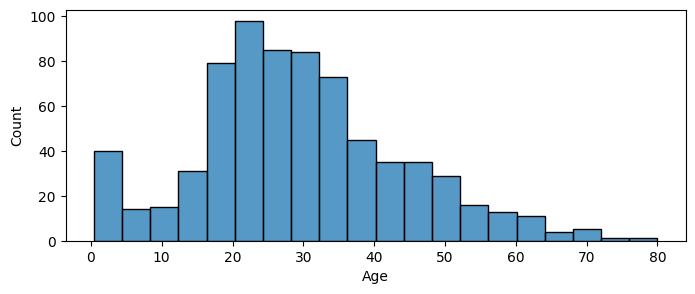

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

#시본에서도 plt.figure()의 figsize 인자를 입력하여 전체 Figure의 크기 조절
plt.figure(figsize=(8,3))

#DataFrame의 칼럼명을 자동으로 인식해서 xlabel 값을 할당. ylabel 값은 Count로 설정.
sns.histplot(titanic_df['Age'], bins=20)
plt.show()

#bins=n: x축 값을 n개의 막대로 나눔


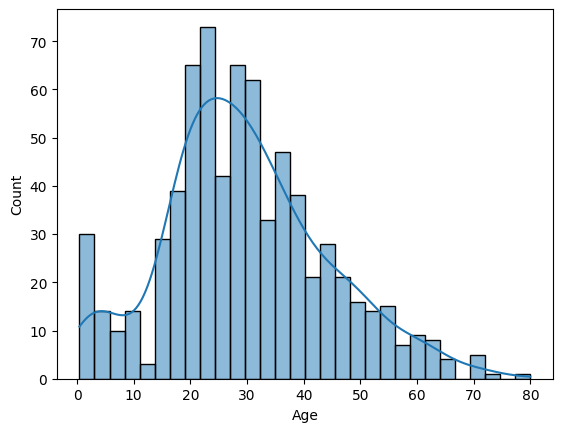

In [4]:
sns.histplot(x='Age',data=titanic_df,bins=30,kde=True)
plt.show()


<Figure size 800x400 with 0 Axes>

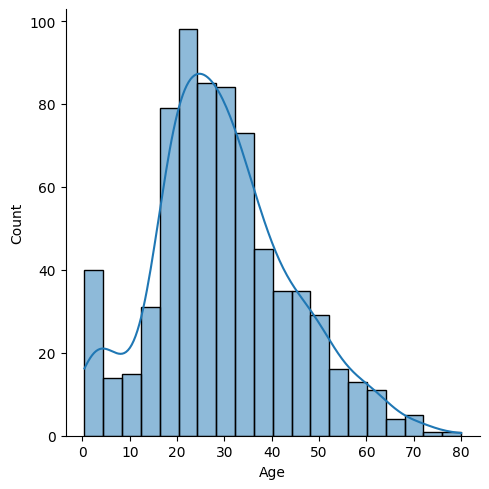

In [5]:
import seaborn as sns
#seaborn의 figure레벨 그래프는 plt.figure()로 Figure 크기를 조절할 수 없음.
plt.figure(figsize=(8,4))
sns.displot(x='Age', data=titanic_df, kde=True)
plt.show()

#오히려 세로가 더 긴 히스토그램으로 만들어짐.


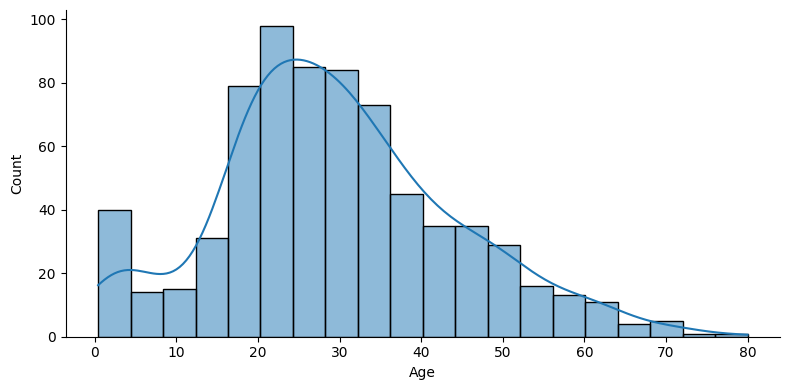

In [6]:
#displot()함수의 Figure 크기를 조절하기 위한 인자: height-세로,aspect-가로 세로 배율
import seaborn as sns
sns.displot(titanic_df['Age'],kde=True, height=4, aspect=2)
plt.show()

<카운트 플롯>

-이산형 값의 건수를 막대 그래프로 시각화. 주로 카테고리성 칼럼 값별 건수를 시각화하는데 사용

-countplot()

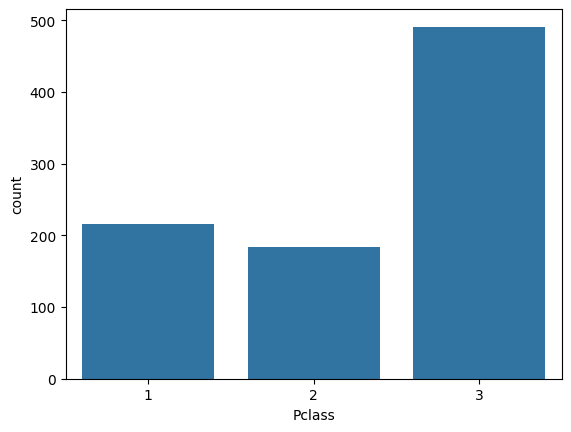

In [7]:
sns.countplot(x='Pclass',data=titanic_df)
plt.show()

<바 플롯>

-barplot()

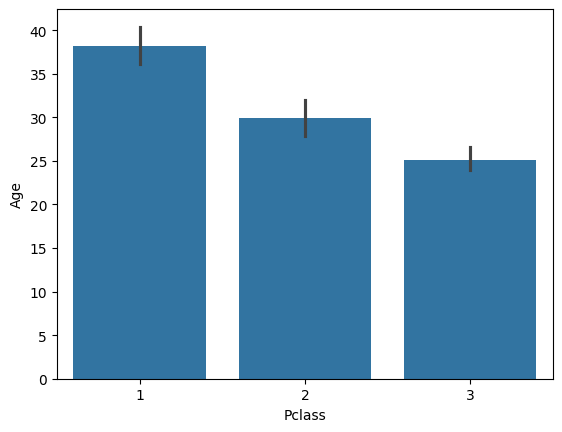

In [9]:
# 자동으로 xlabel, ylabel을 barplot()의 x인자 값인 Pclass,y 인자값이 Age로 설정.
sns.barplot(x='Pclass',y='Age',data=titanic_df)
plt.show()

#시본에서는 맷플롯립과 다르게 pyplot 모듈의 xlabel(),ylabel() 함수를 사용하지 않고도
#x축명 Pclass와 y축명 Age를 자동으로 설정

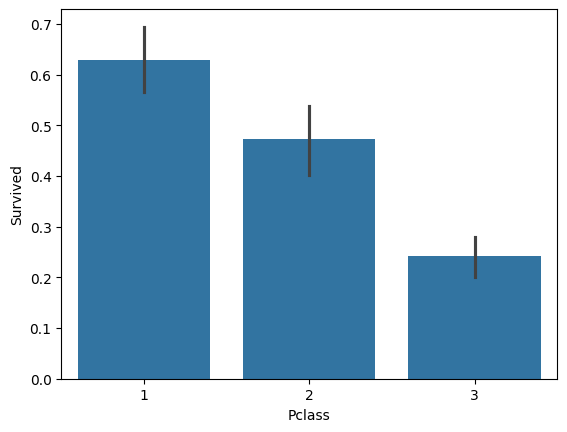

In [10]:
sns.barplot(x='Pclass',y='Survived',data=titanic_df)
plt.show()

#survived 칼럼은 0,1 두 개의 값으로 구성.즉 평균 survived값,평균 생존율

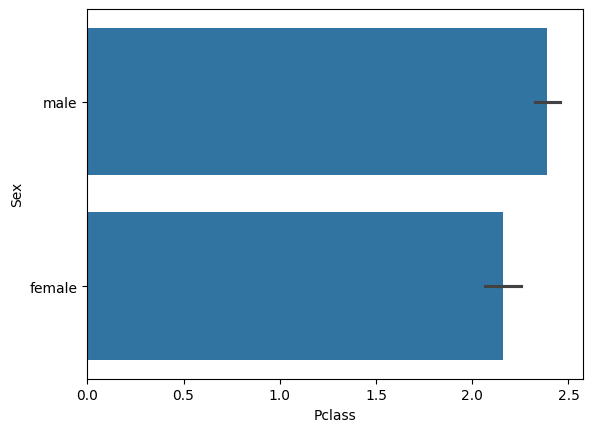

In [12]:
### y축을 문자깂으로 설정하면 자동으로 수평 막대 그래프 변환
sns.barplot(x='Pclass',y='Sex',data=titanic_df)
plt.plot()

##바 플롯은 수평 막대 그래프의 경우 x축 값, 수직의 경우 y축 값이 연속형 값을 기대함.
#때문에 수평 막대 그래프의 x축 값인 Pclass가 평균값으로 만들어져서 표현. 원래는 1,2,3 이산값!

x,y축 모두 이산값을 입력하면 정보를 시각적으로 잘못 이해될 수 있음.

수직-y축 연속, 수평-x축 연속이어야 해석 오류x x,y축 모두 문자열이면 안됨

<Axes: xlabel='Name', ylabel='Sex'>

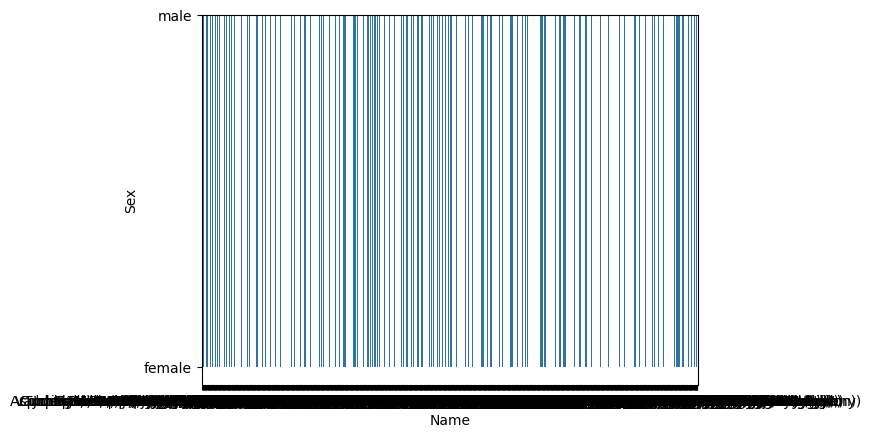

In [15]:
# x 인자로 문자열인 Name, y인자로 문자열인 Sex를 입력하므로 barplot 오류 발생
sns.barplot(x='Name',y='Sex', data=titanic_df)


/tmp/ipykernel_1003/629256275.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass',y='Survived', data=titanic_df, ci=None, estimator=sum)


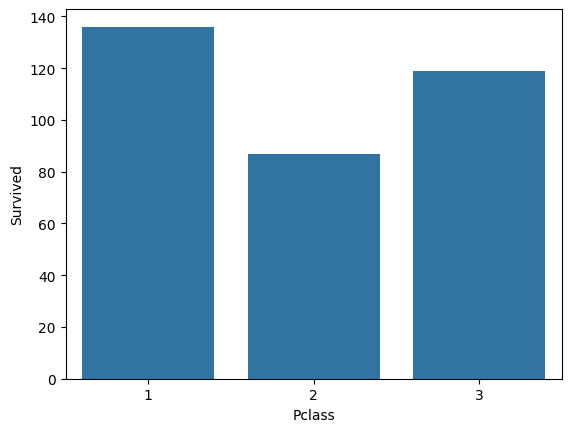

In [16]:
#estimator=sum을 적용하여 y축 표현값을 평균이 아니라 총합으로 표현=선실 등급별 생존자 수
sns.barplot(x='Pclass',y='Survived', data=titanic_df, ci=None, estimator=sum)
plt.show()


<barplot() 함수의 hue 인자를 사용하여 시각화 정보를 추가적으로 세분화하기>


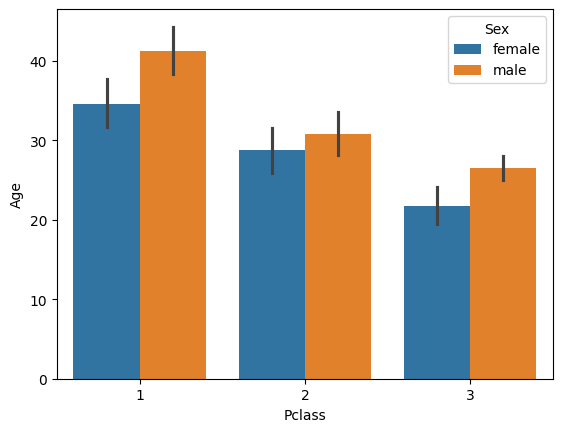

In [18]:
# 아래는 Pclass가 x축값이며 hue파라미터로 Sex를 설정
# 개별 Pclass 값별로 Sex에 따른 Age 평균 값을 구함
sns.barplot(x='Pclass',y='Age', hue='Sex', data=titanic_df)
plt.show()

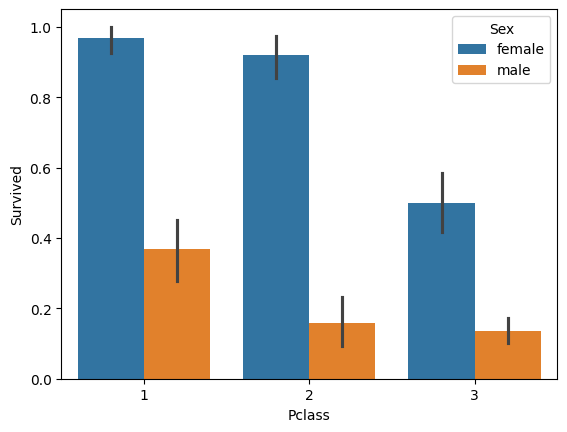

In [19]:
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=titanic_df)
plt.show()

<박스 플롯>

x에 연속형 입력 시 수평 박스 플롯, y에 입력 시 수직 박스 플롯

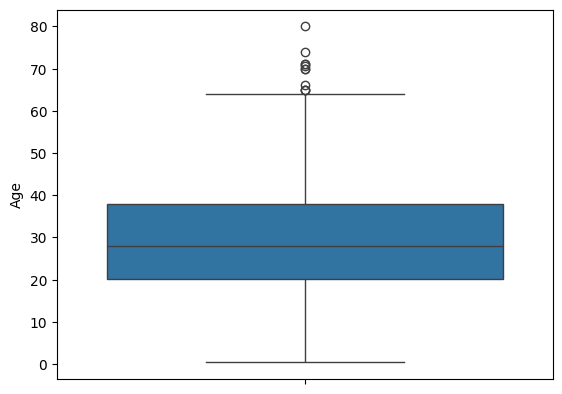

In [20]:
sns.boxplot(y='Age',data=titanic_df)
plt.show()

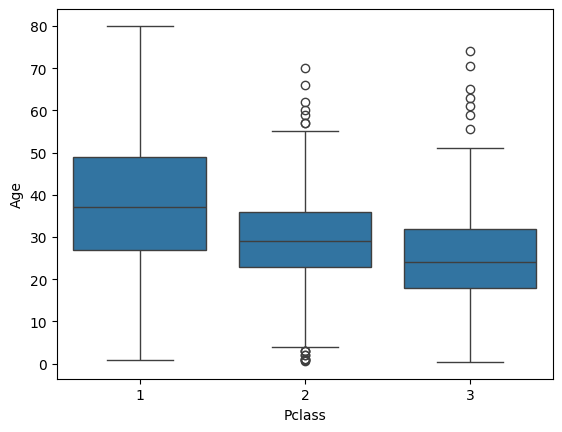

In [21]:
# 여러 개의 수직 박스 플롯을 표현하고자 한다면 반드시 x는 이산형
sns.boxplot(x='Pclass',y='Age',data=titanic_df)
plt.show()

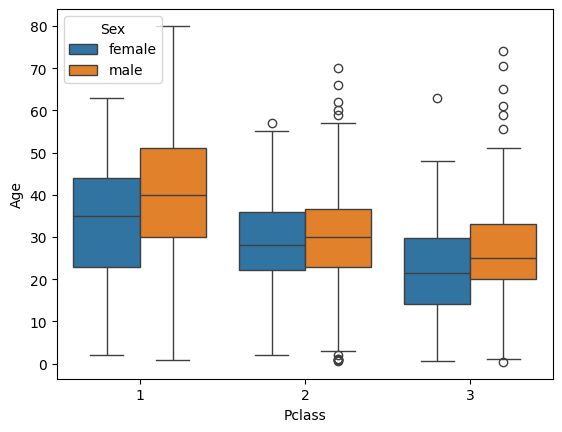

In [22]:
sns.boxplot(x='Pclass',y='Age',hue='Sex', data=titanic_df)
plt.show()

<바이올린 플롯>

x에 연속형-수평 바이올린 플롯, y에 연속형-수직 바이올린 플롯

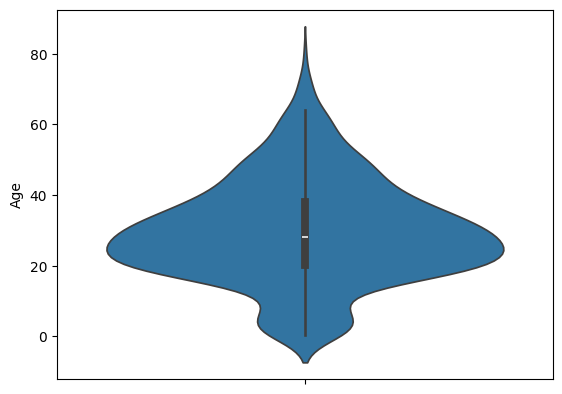

In [23]:
# Age 칼럼에 대한 수직 바이올린 플롯 시각화
sns.violinplot(y='Age',data=titanic_df)
plt.show()

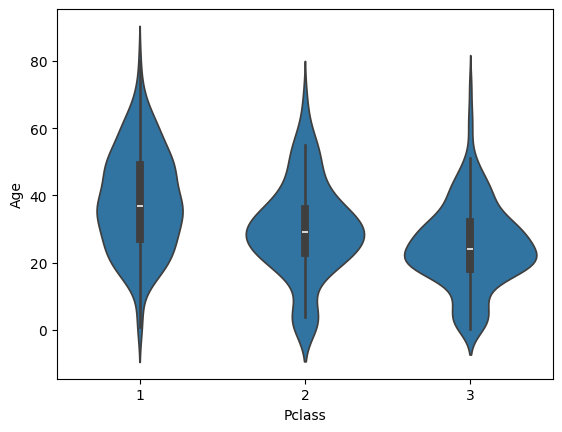

In [24]:
#x축 값인 Pclass의 갑별로 y축 값인 Age의 바이올린 플롯을 그림
#Pclass값별 Age 데이터 분포를 비교
sns.violinplot(x='Pclass',y='Age',data=titanic_df)
plt.show()

#1등실 승객 나이:30대 초반~40대 후반까지 비교적 넓은 범위에 완만하게 집중
#2,3등식 승객나이: 20대 중반~30대 초반까지 상대적으로 좁은 범위에 집중

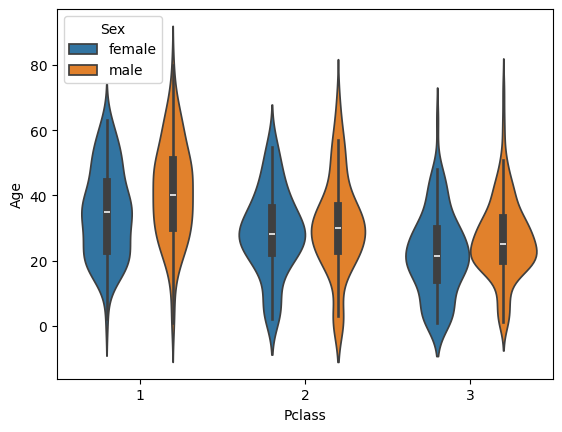

In [25]:
# x축값인 개별 Pclass 내에서 Sex값별로 y축 값인 Age의 바이올린 플롯을 그림
sns.violinplot(x='Pclass',y='Age',hue='Sex',data=titanic_df)
plt.show()

#1등급: 남성이 여성보다 상대적으로 높은 나이대
#2등급: 남성 여성 비슷
#3등급: 남성이 좀 더 청장년층에 집중, 여성은 좀 더 전 연령층 분포

<subplots를 이용하여 시본의 다양한 그래프를 시각화>
- 시본의 모든 Axes레벨 시각화 함수는 ax 인자를 가짐
- 시각화 함수 호출 시 이 ax에 개별 Axes 객체를 할당

ex)fig, axs=plt.subplots(nrows=1,ncols=3)

-> sns.countplot(x=칼럼명,data=dataframe,ax=axs[0])

index: 0
index: 1
index: 2


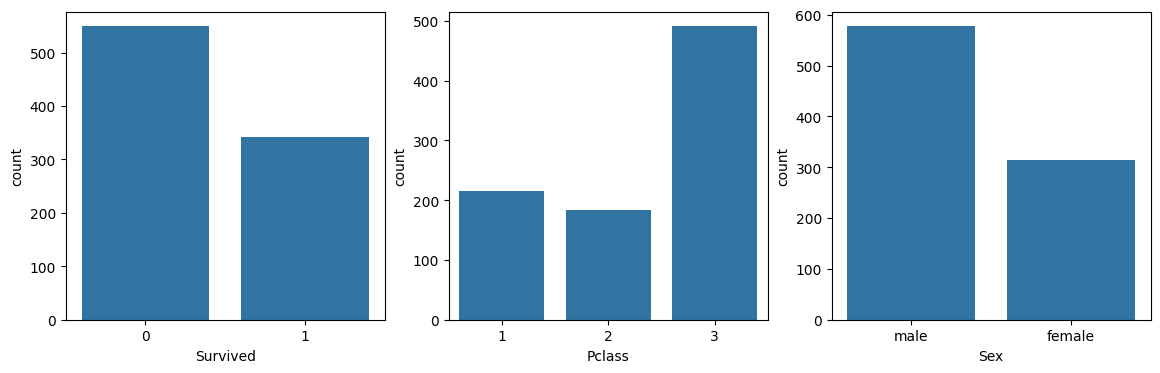

In [27]:
cat_columns=['Survived','Pclass','Sex']

#nrows는 1, ncols는 칼럼 개수만큼인 subplots를 설정
fig,axs=plt.subplots(nrows=1,ncols=len(cat_columns),figsize=(14,4))

for index, column in enumerate(cat_columns):
  print('index:',index)
  #seaborn의 Axes 레벨 function들은 ax 인자로 subplots의 어느 Axes에 위치할지 설정
  sns.countplot(x=column, data=titanic_df,ax=axs[index])

복습)) subplot: 하나의 그래프 창(Figure)을 여러 개의 구역으로 나누어 여러 개의 그래프를 한 화면에 모아서 그릴 때 사용하는 기능

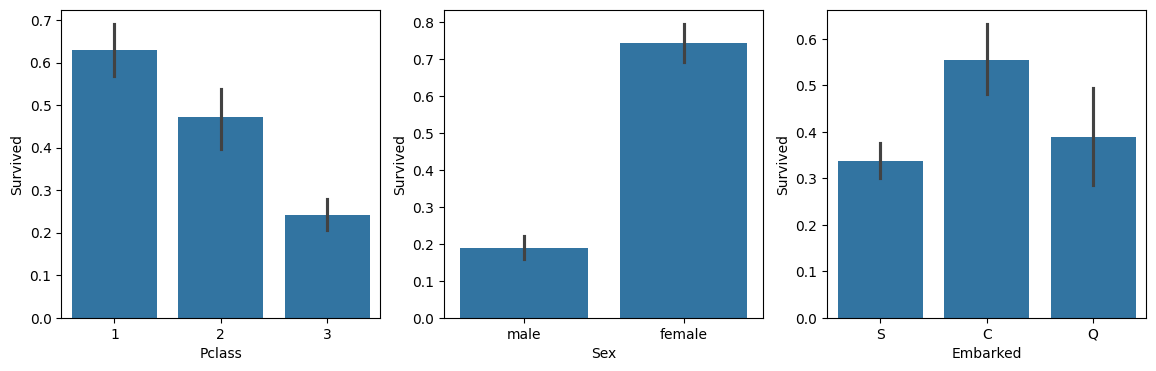

In [28]:
cat_columns=['Pclass', 'Sex','Embarked']

#nrows 1, ncols는 칼럼의 개수만큼 subplots 설정
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14,4))

for index, column in enumerate(cat_columns):
  # seaborn의 Axes 레벨 function들은 ax 인자로 subplots의 어느 Axes에 위치할지 설정.
  sns.barplot(x=column, y='Survived',data=titanic_df, ax=axs[index])
